In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import inspect
from scipy.stats import pearsonr
import time

## Вправи з кореляції

### Завдання 4.1

Кореляція Пірсона
$$
\rho = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}
$$


Косинусна подібність 

$$
\cos(\theta_{\mathbf{x},\mathbf{y}}) = \frac{\alpha}{\|\mathbf{x}\|\|\mathbf{y}\|},
$$
де $\alpha = \mathbf{x}^{\top}\mathbf{y}$ (скалярний добуток).


In [5]:
#Вектори
v1 = np.array([4, 5, 1])
v2 = np.array([-4, 0, -4])


In [6]:
def pearson_correlation(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    num = 0
    den_x = 0
    den_y = 0
    for i in range(len(x)):
        num += (x[i] - mean_x) * (y[i] - mean_y)
        den_x += (x[i] - mean_x) ** 2
        den_y += (y[i] - mean_y) ** 2
    r = num / math.sqrt(den_x * den_y)
    return r

In [7]:
def cosine_similarity(x, y):
    norm_x = np.linalg.norm(x)
    norm_y = np.linalg.norm(y)
    cos = np.dot(x, y) / (norm_x * norm_y)
    return cos

In [8]:
print("Змінні нецентровані:")
print("Кореляція Пірсона:", round(pearson_correlation(v1, v2),3))
print("Косинусна подібність:", round(cosine_similarity(v1,v2),3))
print("\nЗмінні центровані:")

v1_centered = v1 - np.mean(v1)
v2_centered = v2 - np.mean(v2)
print("Кореляція Пірсона:", round(pearson_correlation(v1_centered, v2_centered),3))
print("Косинусна подібність:", round(cosine_similarity(v1_centered,v2_centered),3))


Змінні нецентровані:
Кореляція Пірсона: 0.693
Косинусна подібність: -0.546

Змінні центровані:
Кореляція Пірсона: 0.693
Косинусна подібність: 0.693


### Завдання 4.2
Давайте продовжимо досліджувати різницю між кореляцією і косинусною подібністю. Створіть змінну, що містить цілі числа від 0 до 3, і другу змінну, рівну першій змінній плюс деяке зміщення. Потім створіть симуляцію, у якій ви систематично варіюєте це зміщення між −50 і +50 (тобто на першій ітерації симуляції друга змінна дорівнюватиме [−50, −49, −48, −47]). У циклі for обчисліть кореляцію і косинусну подібність між двома змінними і збережіть ці результати. Потім побудуйте лінійний графік, що показує, як середнє зміщення впливає на кореляцію і косинусну подібність. Ви повинні відтворити рис. 4.4.

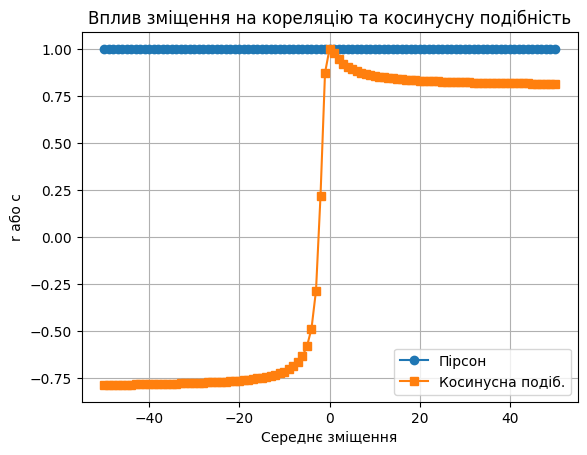

In [9]:
x = [0, 1, 2, 3]  
shifts = range(-50, 51) 
pearsons = []
cosines = []

for shift in shifts:
    y = [xi + shift for xi in x]  
    pearsons.append(pearson_correlation(x, y))
    cosines.append(cosine_similarity(x, y))

plt.plot(shifts, pearsons, 'o-', label="Пірсон")
plt.plot(shifts, cosines, 's-', label="Косинусна подіб.")
plt.xlabel("Середнє зміщення")
plt.ylabel("r або c")
plt.title("Вплив зміщення на кореляцію та косинусну подібність")
plt.legend()
plt.grid(True)
plt.show()

## Завдання 4.3
 У Python є кілька функцій, які обчислюють коефіцієнт кореляції Пірсона. Одна з них називається pearsonr і знаходиться в модулі stats бібліотеки SciPy. Відкрийте вихідний код цього файлу (підказка: ??functionname) і переконайтеся, що ви розумієте, як реалізація на Python співвідноситься з формулами, наведеними в цьому розділі.

In [10]:
print(inspect.getsource(pearsonr))

@xp_capabilities(cpu_only=True, exceptions=['cupy'],
                 jax_jit=False, allow_dask_compute=True)
def pearsonr(x, y, *, alternative='two-sided', method=None, axis=0):
    r"""
    Pearson correlation coefficient and p-value for testing non-correlation.

    The Pearson correlation coefficient [1]_ measures the linear relationship
    between two datasets. Like other correlation
    coefficients, this one varies between -1 and +1 with 0 implying no
    correlation. Correlations of -1 or +1 imply an exact linear relationship.
    Positive correlations imply that as x increases, so does y. Negative
    correlations imply that as x increases, y decreases.

    This function also performs a test of the null hypothesis that the
    distributions underlying the samples are uncorrelated and normally
    distributed. (See Kowalski [3]_
    for a discussion of the effects of non-normality of the input on the
    distribution of the correlation coefficient.)
    The p-value roughly in

## Завдання 4.4

In [11]:
iters = 1000
a = np.random.rand(500)
b = np.random.rand(500)

t1 = time.time()
for _ in range(1000):
    pearson_correlation(a, b)
t2 = time.time()

t3 = time.time()
for _ in range(1000):
    np.corrcoef(a, b)
t4 = time.time()

print("Pearson_correlation:", round(t2 - t1,5), "с")
print("NumPy:", round(t4 - t3,5), "с")

if t2 - t1 < t4 - t3:
    speedup = (((t4 - t3) - (t2 - t1)) / (t4 - t3)) * 100
    print(f"Pearson_correlation швидша за np.corrcoef на {speedup:.2f}%.")
else:
    speedup = (((t2 - t1) - (t4 - t3)) / (t4 - t3)) * 100
    print(f"np.corrcoef швидша за pearson_correlation на {speedup:.2f}%.")

Pearson_correlation: 0.62232 с
NumPy: 0.0911 с
np.corrcoef швидша за pearson_correlation на 583.09%.


# Вправи з фільтрації та виявлення ознак
## Завдання 4.6

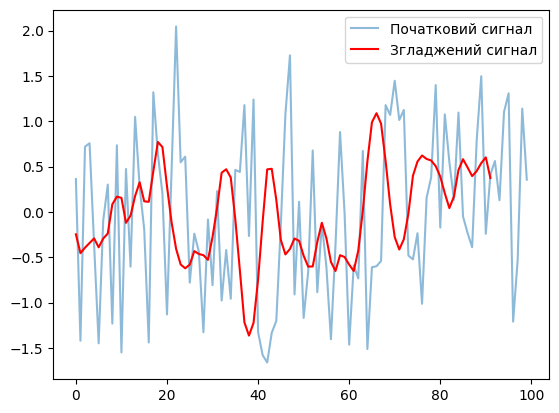

In [8]:
import numpy as np
import matplotlib.pyplot as plt

signal = np.random.randn(100)  # шумовий сигнал
kernel = np.array([0, .1, .3, .8, 1, .8, .3, .1, 0])
kernel = kernel / np.sum(kernel)  # нормалізація

filtered = []

for i in range(len(signal) - len(kernel)+1):
    segment = signal[i:i+len(kernel)]
    value = np.dot(kernel, segment)
    filtered.append(value)

plt.plot(signal, label='Початковий сигнал', alpha=0.5)
plt.plot(filtered, label='Згладжений сигнал', color='red')
plt.legend()
plt.show()

# Вправи з алгоритму $k$- середніх
## Завдання 4.8


Запуск 1


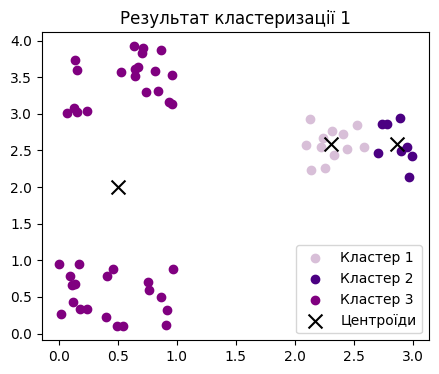


Запуск 2


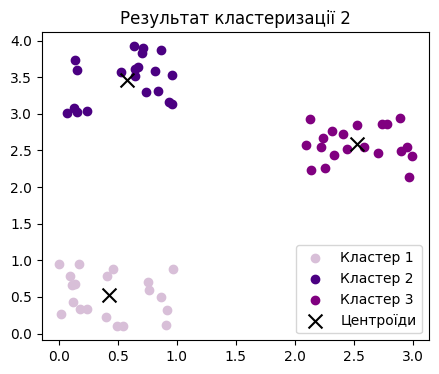


Запуск 3


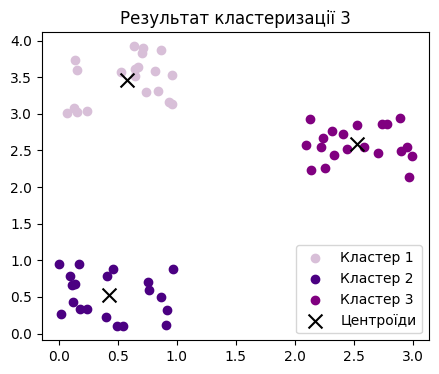

In [ ]:
#створюємо дані
cluster1 = np.random.rand(20, 2) + np.array([0, 0])
cluster2 = np.random.rand(20, 2) + np.array([2, 2])
cluster3 = np.random.rand(20, 2) + np.array([0, 3])
data = np.vstack((cluster1, cluster2, cluster3))

k = 3  # кількість кластерів
num_runs = 3  # скільки разів повторюємо кластеризацію

# повторюємо кілька кластеризацій
for run in range(num_runs):
    print(f"\nЗапуск {run+1}")
    # випадкові центроїди
    ridx = np.random.choice(len(data), k, replace=False)
    centroids = data[ridx, :]

    for iteration in range(10):  # кілька ітерацій уточнення центроїдів
        #обчислюємо відстані до кожного центроїда
        dists = np.zeros((data.shape[0], k))
        for ci in range(k):
            dists[:, ci] = np.sum((data - centroids[ci, :])**2, axis=1)
        #призначаємо кожну точку до найближчого центроїда
        groupidx = np.argmin(dists, axis=1)
        # оновлюємо центроїди
        for ki in range(k):
            if np.any(groupidx == ki):
                centroids[ki, :] = np.mean(data[groupidx == ki, :], axis=0)

 
    colors = ['thistle', 'indigo', 'purple']
    plt.figure(figsize=(5, 4))
    for ki in range(k):
        plt.scatter(data[groupidx == ki, 0],
                    data[groupidx == ki, 1],
                    c=colors[ki], label=f'Кластер {ki+1}')
    plt.scatter(centroids[:, 0], centroids[:, 1],
                c='black', marker='x', s=100, label='Центроїди')
    plt.title(f'Результат кластеризації {run+1}')
    plt.legend()
    plt.show()


## Завдання 4.9

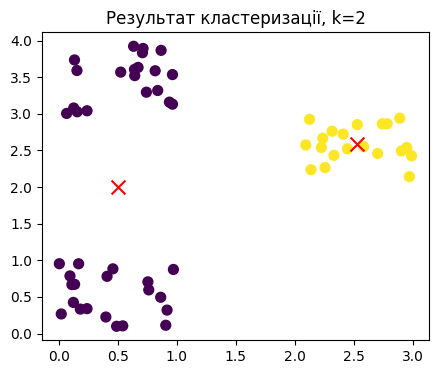

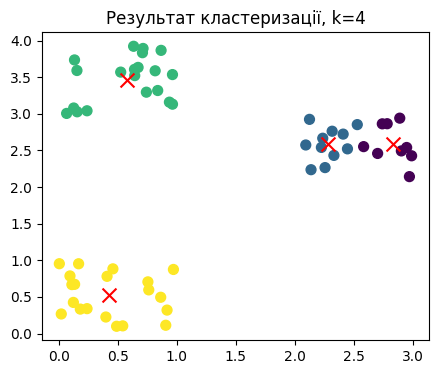

In [14]:
for k in [2, 4]:
    ridx = np.random.choice(len(data), k, replace=False)
    centroids = data[ridx, :]

    for _ in range(10):
        dists = np.zeros((data.shape[0], k))
        for ci in range(k):
            dists[:, ci] = np.sum((data - centroids[ci, :])**2, axis=1)
        groupidx = np.argmin(dists, axis=1)
        for ki in range(k):
            if np.any(groupidx == ki):
                centroids[ki, :] = np.mean(data[groupidx == ki, :], axis=0)

    plt.figure(figsize=(5, 4))
    plt.scatter(data[:,0], data[:,1], c=groupidx, cmap='viridis', s=50)
    plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='x', s=100)
    plt.title(f"Результат кластеризації, k={k}")
    plt.show()